Librerias

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import zipfile
import io
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
                             accuracy_score, roc_curve, roc_auc_score, RocCurveDisplay, make_scorer, mean_squared_error)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from google.colab import files

# Subir los archivos df_respondieron y df_norespondieron desde la computadora
uploaded = files.upload()

Saving df_respondieron.xlsx to df_respondieron.xlsx
Saving df_no_respondieron.xlsx to df_no_respondieron.xlsx


In [3]:
for filename, content in uploaded.items():
  # Crear dataframe
  df_name = os.path.splitext(filename)[0] # Nombre de archivo sin extension
  globals()[df_name] = pd.read_excel(io.BytesIO(content))
  print(f"Dataframe creado: {df_name}")

Dataframe creado: df_respondieron
Dataframe creado: df_no_respondieron


In [4]:
# ------------ 0. Copia de trabajo -------------
base = df_respondieron.copy()

base['ingreso_pc_cero']     = (base['p47t'] == 0).astype(int)
base['ingreso_pc_fam_cero'] = (base['ipcf'] == 0).astype(int)
base['t_vi_cero']           = (base['t_vi'] == 0).astype(int)
base['itf_cero']            = (base['itf'] == 0).astype(int)

# ------------ 1. Filtro de outliers y ceros 1-99 % -------------
def pct_filter(df, col, p_low=1, p_high=99):
    p1, p99 = np.percentile(df[col], [p_low, p_high])
    return df[(df[col] >= p1) & (df[col] <= p99)]

for col in ['p47t', 'ipcf', 'itf', 't_vi']:
    base = pct_filter(base, col)


# ------------ 2. Variables -------------
base['edad']        = base['ch06']
base['edad_sq']     = base['edad']**2

base['log_ingreso_pc'] = np.log1p(base['p47t'])            # 0 -> 0
base['log_ipcf']       = np.log1p(base['ipcf'])
base['log_t_vi']       = np.log1p(base['t_vi'])

base['itf_ratio'] = np.where(base['ipcf'] > 0,
                             base['itf'] / base['ipcf'],
                             0)                            # evita inf
# variables de interacción
base['edu_age_int'] = base['anios_educ'] * base['edad'] # edad x educacion

base['male_single']   = base['ch04_varón'] * base['ch07_soltero']
base['female_single'] = (1 - base['ch04_varón']) * base['ch07_soltero']

# filtrar outliers de la interacción
base = pct_filter(base, 'edu_age_int')

cont_vars = ['edad','edad_sq','log_ingreso_pc','log_ipcf',
             'itf_ratio','edu_age_int','log_t_vi']

# Variables categóricas para los barplots de proporciones
cat_vars  = ['ch04_varón','ch07_soltero',
             'nivel_ed_sin instrucción',
             'ingreso_pc_cero','ingreso_pc_fam_cero',
             'itf_cero','t_vi_cero', 'male_single', 'female_single']


In [5]:
# 1. Diccionarios de títulos
titulos_cont = {
    'edad'             : 'Distribución de la edad (años)',
    'edad_sq'          : 'Edad al cuadrado',
    'log_ingreso_pc'   : 'Log-ingreso individual',
    'log_ipcf'         : 'Log-ingreso per cápita familiar',
    'itf_ratio'        : 'Ingreso total familiar / Ingreso per cápita familiar',
    'edu_age_int'      : 'Interacción edad × años de educación',
    'log_t_vi'         : 'Log-ingresos no laborales',
}

titulos_cat = {
    'ch04_varón'                      : 'Proporción de: varones',
    'ch07_soltero'                    : 'Personas solteras',
    'nivel_ed_sin instrucción'        : 'Sin instrucción',
    'itf_cero'                        : 'Sin Ingresos familiares'}

# variables con etiqueta y
ylabel_cont = {'edad', 'log_ingreso_pc', 'itf_ratio'}
ylabel_cat  = {'ch04_varón', 'nivel_ed_sin instrucción'}



In [6]:
# Features finales:
cat_vars  = ['ch04_varón','ch07_soltero','nivel_ed_sin instrucción','itf_cero', 'female_single']

cont_vars = ['edad','edad_sq','log_ingreso_pc',
             'itf_ratio','edu_age_int','log_t_vi']

In [7]:
# Matriz de correlaciones y VIF
# --- Selección de columnas numéricas que entran al modelo ---
# 1. Construimos X
X = base[cont_vars + cat_vars].copy()

# 2. Escalar solo continuas
X[cont_vars] = StandardScaler().fit_transform(X[cont_vars])

# 3. Asegurar que TODOS los cat_vars sean numéricos (0/1) y float
X[cat_vars] = X[cat_vars].astype(float)          # de bool/int → float

# 4. Eliminar columnas que quedaron constantes (var = 0) — evitan VIF infinito
const_cols = [c for c in X.columns if X[c].var() == 0]
if const_cols:
    print("Columnas constantes eliminadas:", const_cols)
    X = X.drop(columns=const_cols)

# 5. Eliminar filas con NaN/inf que pudieran haber quedado
X = X.replace([np.inf, -np.inf], np.nan).dropna()



In [8]:
# Split año por año con random_state=444
def split_by_year(df, year, Xcols, ycol='desocupado'):
    df_y = df[df['ano4'] == year].copy()
    X, y = df_y[Xcols], df_y[ycol]
    return train_test_split(X, y, test_size=0.30,
                            random_state=444, stratify=y)

Xcols = cont_vars + cat_vars            # todas las features

X_train04, X_test04, y_train04, y_test04 = split_by_year(base, 2004, Xcols)
X_train24, X_test24, y_train24, y_test24 = split_by_year(base, 2024, Xcols)

# Columna de 1s
for Xset in [X_train04, X_test04, X_train24, X_test24]:
    Xset['const'] = 1.0

In [9]:
# Estandarización SOLO de continuas
pre = ColumnTransformer(
        [('num', StandardScaler(), cont_vars)],
        remainder='passthrough')        # dummies y “const” se dejan igual


# TP 4

In [10]:
# Función de Logit penalizado
# ------------------------------------------------------------------
def logit_penalizado_full(X_tr, X_te, y_tr, y_te,
                          penalty, C=1.0, solver='saga', # solver recomendado por sci-kit learn
                          titulo=''):
    """Devuelve dict con cm, acc, auc, mse_test"""

    model = LogisticRegression(
        penalty=penalty, C=C, solver=solver, max_iter=5000, random_state=444
    )
    pipe = Pipeline([('pre', pre), ('clf', model)])
    pipe.fit(X_tr, y_tr)

    y_hat  = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_hat)
    auc  = roc_auc_score(y_te, y_prob)
    mse  = mean_squared_error(y_te, y_prob)
    cm   = confusion_matrix(y_te, y_hat)

    # --- gráficos -------------------------
    ConfusionMatrixDisplay(cm,
        display_labels=['No desocupado', 'Desocupado']
    ).plot(cmap='Blues')
    plt.title(f'{titulo} | Acc={acc:.3f}  AUC={auc:.3f}')
    plt.show()

    RocCurveDisplay.from_predictions(y_te, y_prob)
    plt.title(f'ROC – {titulo}')
    plt.show()

    return {'cm':cm, 'acc':acc, 'auc':auc, 'mse':mse}


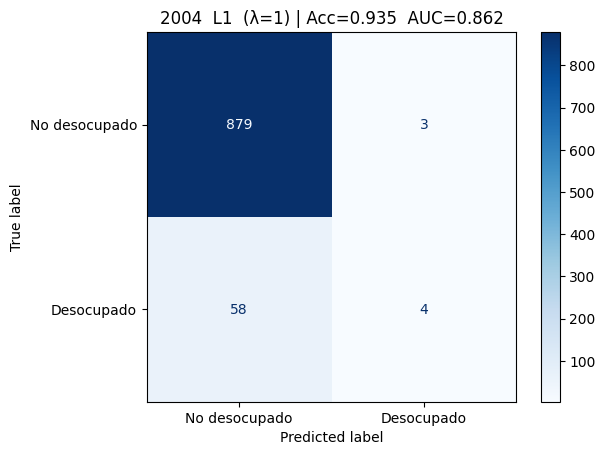

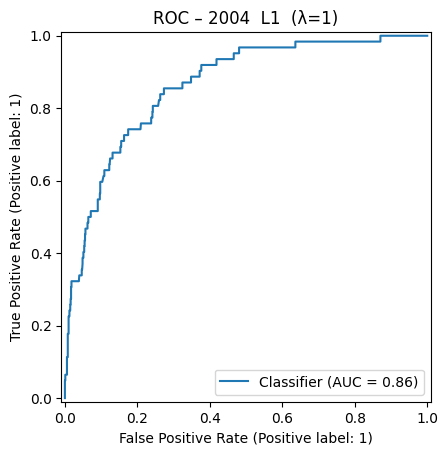

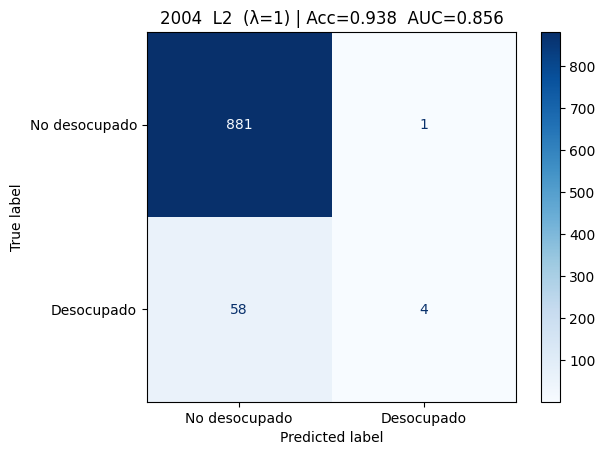

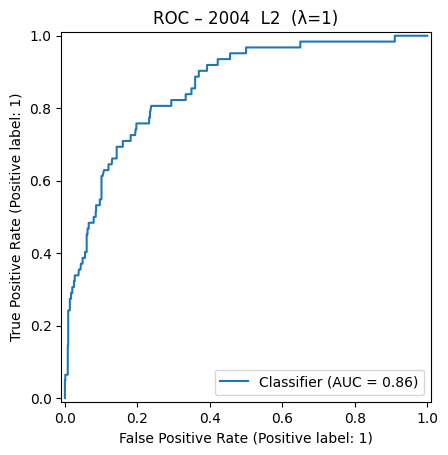

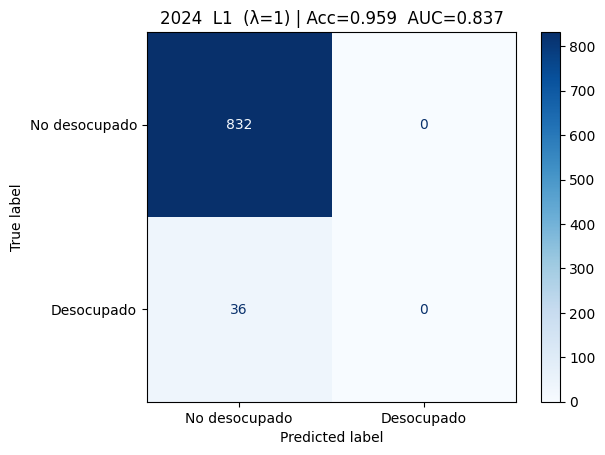

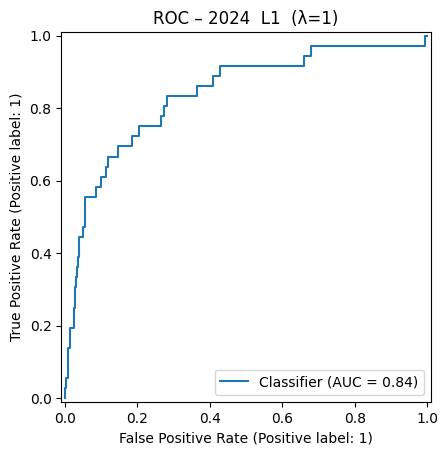

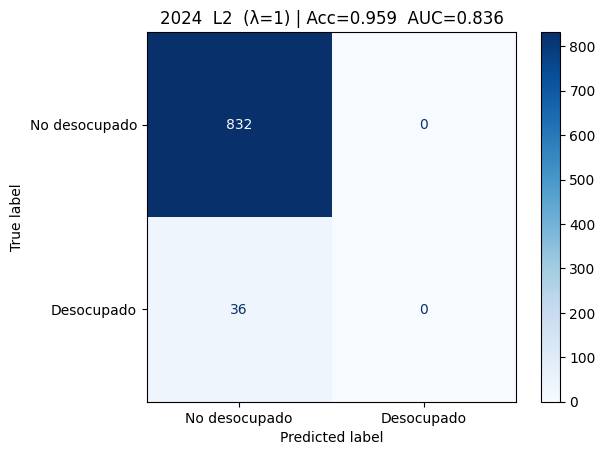

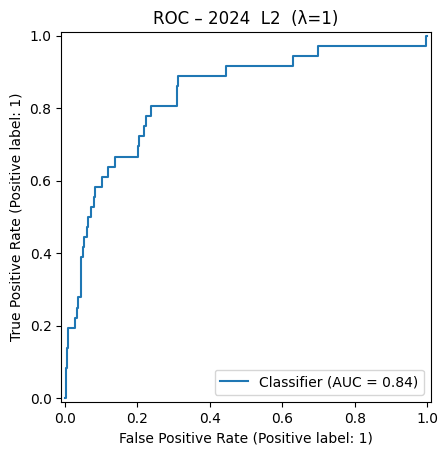

acc    auc    mse
2004 L1  0.935  0.862  0.050
     L2  0.938  0.856  0.051
2024 L1  0.959  0.837  0.035
     L2  0.959  0.836  0.036

In [11]:
# Resultados de LASSO y Ridge
# ------------------------------------------------------------------
base_results = {}

for year, Xtr, Xte, ytr, yte in [
        ('2004', X_train04, X_test04, y_train04, y_test04),
        ('2024', X_train24, X_test24, y_train24, y_test24)]:

    base_results[year] = {}
    base_results[year]['L1'] = logit_penalizado_full(
        Xtr, Xte, ytr, yte,
        penalty='l1', C=1.0,
        titulo=f'{year}  L1  (λ=1)'
    )
    base_results[year]['L2'] = logit_penalizado_full(
        Xtr, Xte, ytr, yte,
        penalty='l2', C=1.0,
        titulo=f'{year}  L2  (λ=1)'
    )

# --- resumen rápido ---
(
    pd.DataFrame({(y,m): d for y,v in base_results.items() for m,d in v.items()})
      .loc[['acc','auc','mse']]          # 1) sólo métricas numéricas
      .T                                 # 2) cada columna = métrica
      .astype(float)                     # 3) fuerza dtype float
      .round(3)                          #
)

In [12]:
# ----------------------------------------------------------------------------------------
# Función de Cross-validation y media de la proporción de variables eliminadas por LASSO
# ----------------------------------------------------------------------------------------
def cv_logit_con_coefs(
        penalty,                         # 'l1' (LASSO) ó 'l2' (Ridge)
        X_train, y_train,
        cont_vars, cat_vars,
        exponents = range(-5, 6),        # n  →  λ = 10**n  (1e-5 … 1e5)
        n_folds   = 10,                  # k-fold = 10-fold
        random_state = 444
    ):
    """
    Devuelve:
      λ_opt             → exponente (n) con menor MSE_CV
      df_resultados      columnas: ['λ', 'MSE_CV', 'prop0']   (prop0 sólo L1)
    """
    solver = 'saga'
    kf     = StratifiedKFold(
        n_splits=n_folds, shuffle=True, random_state=random_state
    )

    lambdas = [10.0 ** n for n in exponents]     # lista de λ
    mse_cv  = []
    prop0   = []                                 # sólo para L1

    for lam in lambdas:
        C_val = 1.0 / lam          # scikit-learn usa C = 1/λ
        fold_mse  = []
        fold_prop = []

        for tr_idx, vl_idx in kf.split(X_train, y_train):
            X_tr, X_vl = X_train.iloc[tr_idx], X_train.iloc[vl_idx]
            y_tr, y_vl = y_train.iloc[tr_idx], y_train.iloc[vl_idx]

            pipe = Pipeline([
                ('pre', pre),   # ColumnTransformer con scaling
                ('clf', LogisticRegression(
                    penalty=penalty, C=C_val, solver=solver,
                    max_iter=5000, random_state=random_state
                ))
            ])

            pipe.fit(X_tr, y_tr)

            # ---------- MSE en el fold ----------
            prob_vl = pipe.predict_proba(X_vl)[:, 1]
            fold_mse.append(mean_squared_error(y_vl, prob_vl))

            # ---------- % coef = 0 (sólo LASSO) ----------
            if penalty == 'l1':
                coef = pipe.named_steps['clf'].coef_.ravel()
                fold_prop.append((coef == 0).mean())

        mse_cv.append(np.mean(fold_mse))
        if penalty == 'l1':
            prop0.append(np.mean(fold_prop))

    # -------------- dataframe de resultados --------------------------
    df_res = pd.DataFrame({
        'λ'      : exponents,          # guardamos el exponente y el mse del cv
        'MSE_CV' : mse_cv
    })
    if penalty == 'l1':
        df_res['prop0'] = prop0

    # -------------- λ óptimo (exponente n) ---------------------------
    λ_opt_exp = df_res.loc[df_res['MSE_CV'].idxmin(), 'λ']

    return λ_opt_exp, df_res


2004:  λ* Ridge = 10^-1   |   λ* LASSO = 10^-1


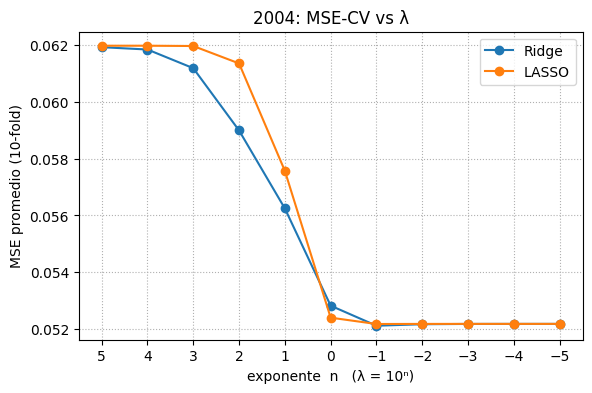

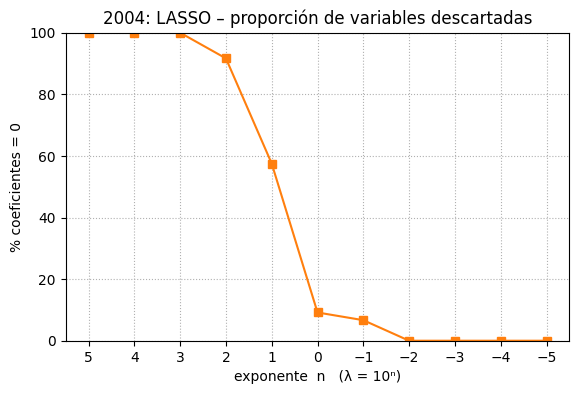

KeyboardInterrupt: 

In [13]:
# ===============================================================
# 1. Barrido λ (10^n, n = -5 … 5)  |  selección óptima por MSE
# ===============================================================
exps = range(-5, 6)         # n ∈ { -5 , … , 5 }   →   λ = 10^n
results = {}                # guardamos todo en un dicccionario

for lbl, Xtr, ytr in [
        ('2004', X_train04, y_train04),
        ('2024', X_train24, y_train24)]:

    results[lbl] = {}

    # ---------- Ridge (L2) ----------
    λopt_exp_L2, df_L2 = cv_logit_con_coefs(
        penalty   = 'l2',
        X_train   = Xtr,
        y_train   = ytr,
        cont_vars = cont_vars,
        cat_vars  = cat_vars,
        exponents = exps
    )
    results[lbl]['Ridge'] = {'λ_exp*': λopt_exp_L2, 'df': df_L2}

    # ---------- LASSO (L1) ----------
    λopt_exp_L1, df_L1 = cv_logit_con_coefs(
        penalty   = 'l1',
        X_train   = Xtr,
        y_train   = ytr,
        cont_vars = cont_vars,
        cat_vars  = cat_vars,
        exponents = exps
    )
    results[lbl]['LASSO'] = {'λ_exp*': λopt_exp_L1, 'df': df_L1}

    print(f"{lbl}:  λ* Ridge = 10^{λopt_exp_L2}   |   λ* LASSO = 10^{λopt_exp_L1}")


    # 1.a  Gráfico  MSE-CV  vs  λ   (ambos métodos)
    # ------------------------------------------------------
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6.5,4))
    plt.plot(df_L2['λ'], df_L2['MSE_CV'], 'o-', label='Ridge')
    plt.plot(df_L1['λ'], df_L1['MSE_CV'], 'o-', label='LASSO')
    plt.gca().invert_xaxis()                    # λ grande a la izquierda
    plt.xticks(df_L2['λ'])                      # -5 … 5
    plt.xlabel('exponente  n   (λ = 10ⁿ)')
    plt.ylabel('MSE promedio (10-fold)')
    plt.title(f'{lbl}: MSE-CV vs λ')
    plt.grid(ls=':')
    plt.legend()
    plt.show()


    # 1.b  Gráfico  % coef = 0  vs  λ   (solo LASSO)
    # ------------------------------------------------------
    plt.figure(figsize=(6.5,4))
    plt.plot(df_L1['λ'], df_L1['prop0']*100, 's-', color='tab:orange')
    plt.gca().invert_xaxis()
    plt.xticks(df_L1['λ'])
    plt.xlabel('exponente  n   (λ = 10ⁿ)')
    plt.ylabel('% coeficientes = 0')
    plt.title(f'{lbl}: LASSO – proporción de variables descartadas')
    plt.ylim(0, 100)
    plt.grid(ls=':')
    plt.show()

In [14]:
# -------------------------------------------------------------------------
# 2. Variables descartadas con λ* LASSO
# -------------------------------------------------------------------------
for lbl, Xtr, ytr in [
        ('2004', X_train04, y_train04),
        ('2024', X_train24, y_train24)]:

    λ_exp = results[lbl]['LASSO']['λ_exp*']
    C_val = 1.0 / (10.0**λ_exp)

    lasso_best = Pipeline([
        ('pre', pre),
        ('clf', LogisticRegression(
            penalty='l1', C=C_val, solver='saga',
            max_iter=5000, random_state=444))
    ]).fit(Xtr, ytr)

    coef = lasso_best.named_steps['clf'].coef_.ravel()
    vars_zero = [v for v,c in zip(cont_vars + cat_vars, coef) if c == 0]

    print(f"\n{lbl} — λ* LASSO = 10^{λ_exp}")
    print("Variables descartadas:", vars_zero if vars_zero else '— ninguna —')



2004 — λ* LASSO = 10^-1
Variables descartadas: — ninguna —


KeyError: 'LASSO'

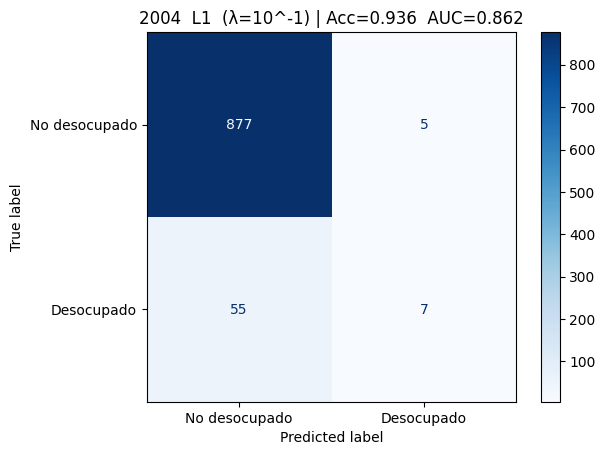

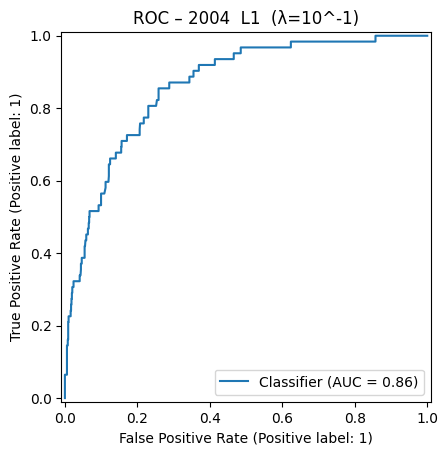

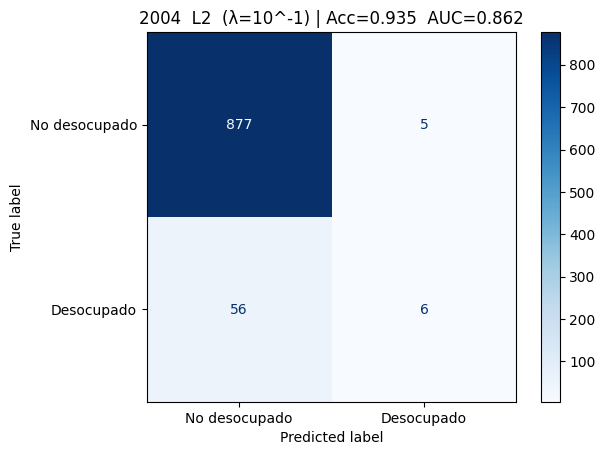

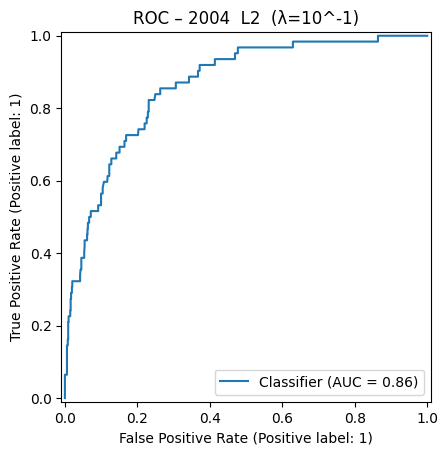

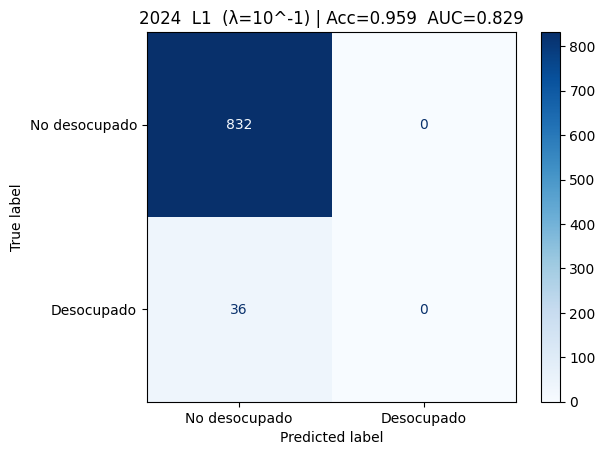

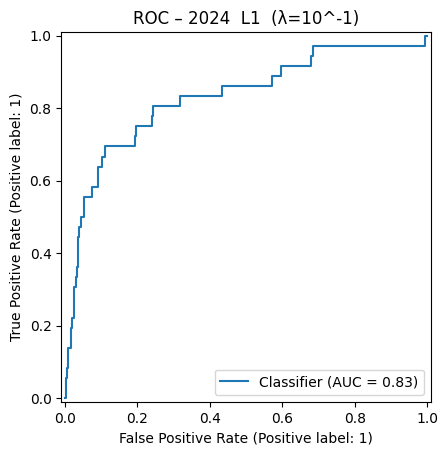

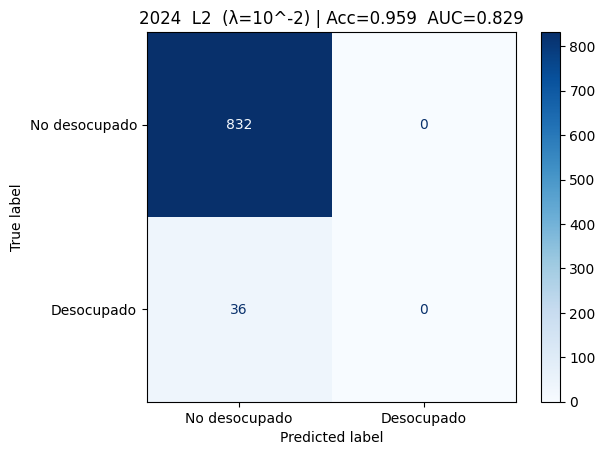

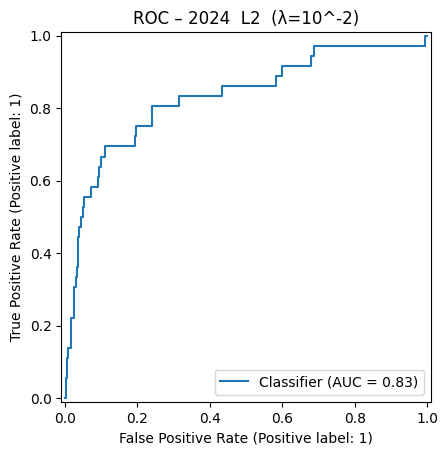

mse    acc    auc
2004 L1  0.050  0.936  0.862
     L2  0.050  0.935  0.862
2024 L1  0.035  0.959  0.829
     L2  0.035  0.959  0.829

In [ ]:
# ==========================================================
# 6. Evaluación TEST con λ* de CV  (MSE, ACC, AUC)
#     usando función logit_penalizado_full
# ==========================================================
base_results_opt = {}

for year, Xtr, Xte, ytr, yte in [
        ('2004', X_train04, X_test04, y_train04, y_test04),
        ('2024', X_train24, X_test24, y_train24, y_test24)]:

    # ---- λ* de CV (exponente n) ----
    λexp_L1 = results[year]['LASSO']['λ_exp*']   # exponente óptimo LASSO
    λexp_L2 = results[year]['Ridge']['λ_exp*']   # exponente óptimo Ridge

    # ---- C = 1 / λ ----
    C_L1 = 1.0 / (10.0 ** λexp_L1)
    C_L2 = 1.0 / (10.0 ** λexp_L2)

    base_results_opt[year] = {}

    # ---------- LASSO ----------
    base_results_opt[year]['L1'] = logit_penalizado_full(
        Xtr, Xte, ytr, yte,
        penalty='l1', C=C_L1,
        titulo=f'{year}  L1  (λ=10^{λexp_L1})'
    )

    # ---------- Ridge ----------
    base_results_opt[year]['L2'] = logit_penalizado_full(
        Xtr, Xte, ytr, yte,
        penalty='l2', C=C_L2,
        titulo=f'{year}  L2  (λ=10^{λexp_L2})'
    )

# --------- Resumen en tabla ----------
resumen = (
    pd.DataFrame({
        (año, método): metr
        for año, dic in base_results_opt.items()
        for método, metr in dic.items()
    })
    .loc[['mse', 'acc', 'auc']]   # solo las métricas numéricas
    .T                            # filas = (año, método)
    .apply(pd.to_numeric, errors='coerce')   # convierte a float
    .round(3)                     # redondea a 3 sf
)

display(resumen)


2004:  prof. óptima = 26


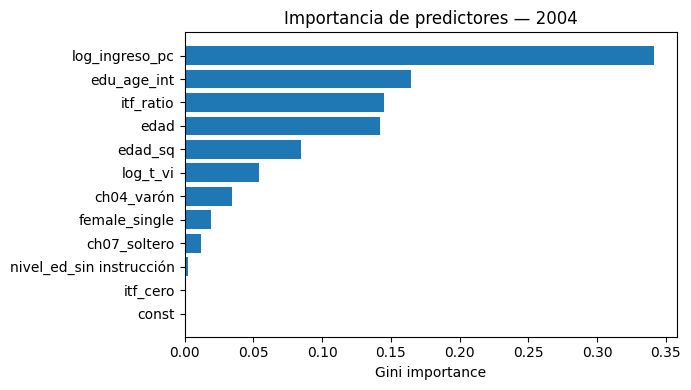

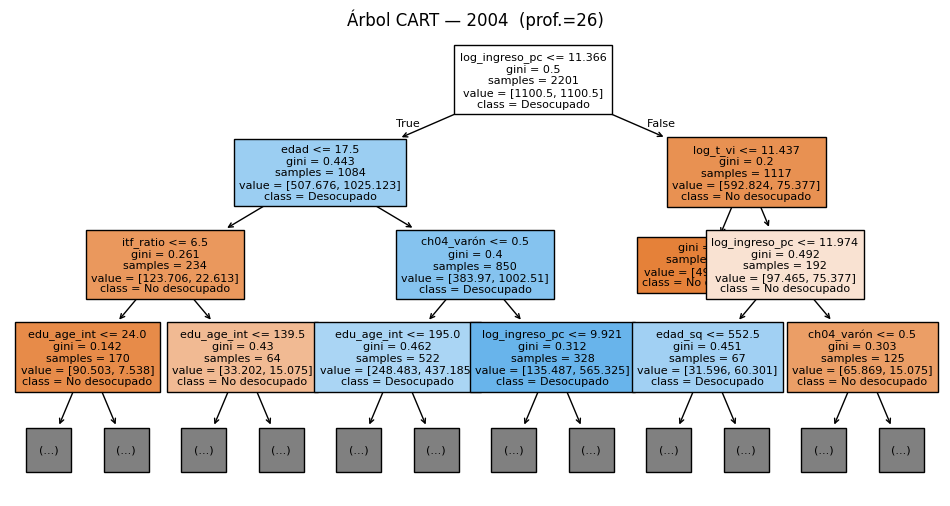

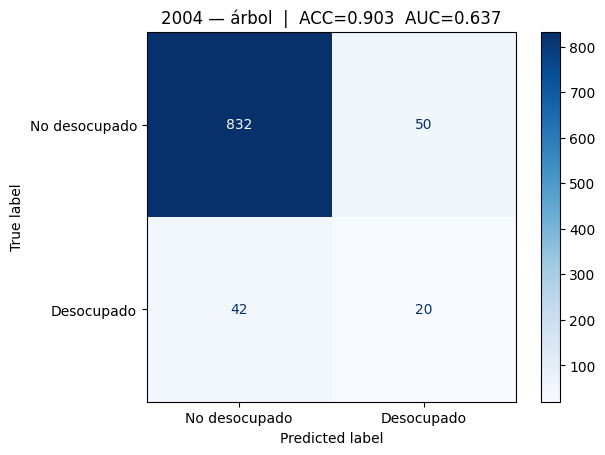

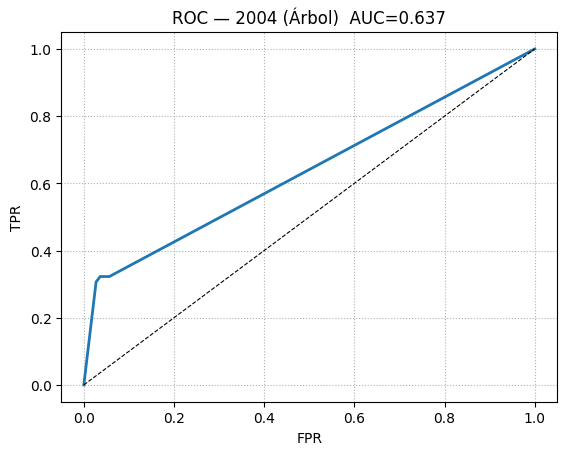

2004 | MSE test (árbol) = 0.090
2024:  prof. óptima = 17


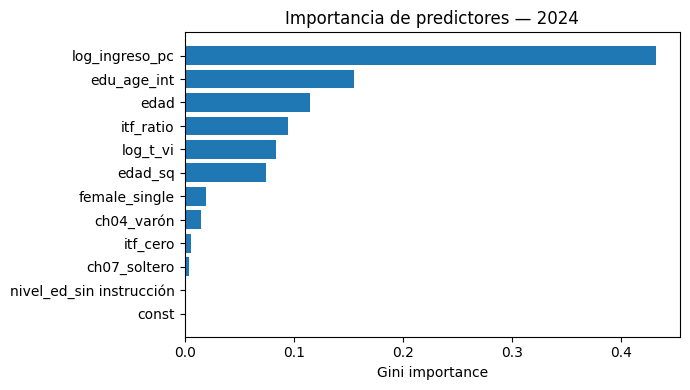

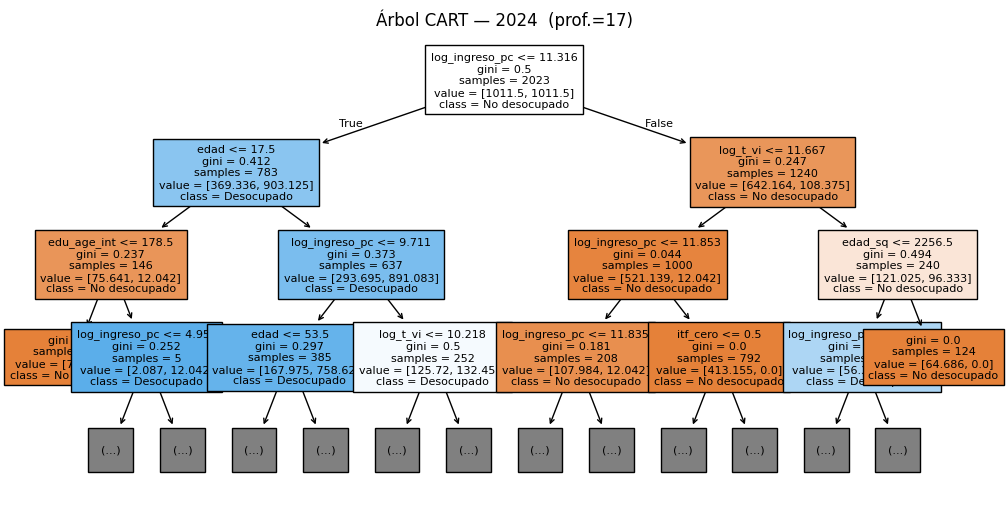

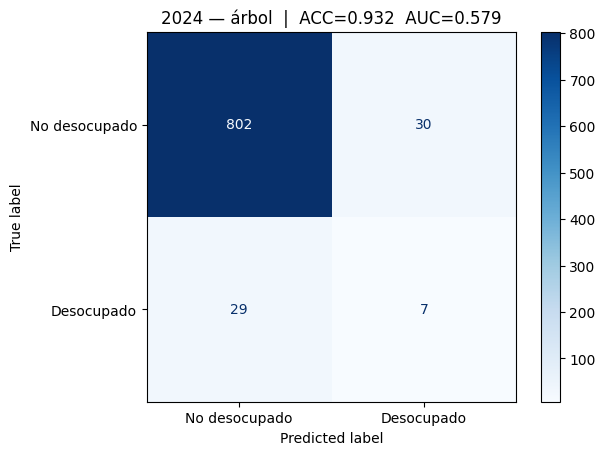

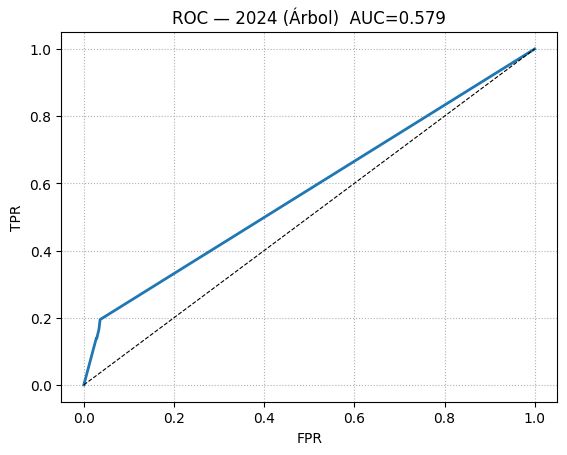

2024 | MSE test (árbol) = 0.067


In [ ]:
# ------------------------------------------------------------------
# 1. Pipeline que solo one-hot-encodea (el árbol no necesita scaler)
# ------------------------------------------------------------------

def tree_cv_train(X_tr, y_tr, max_depth_grid=range(1, 100)):
    """Devuelve el árbol óptimo (según MSE-CV) y su GridSearchCV"""

    pre_tree = ColumnTransformer(
        [('passthrough', 'passthrough', X_tr.columns)],
        remainder='passthrough', verbose_feature_names_out=False
    )

    pipe = Pipeline([
        ('prep', pre_tree),
        ('cart', DecisionTreeClassifier(random_state=444,
                                        class_weight='balanced'))
    ])

    param_grid = {'cart__max_depth': list(max_depth_grid)}

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=444) # Cross-validation

    gsearch = GridSearchCV(
        pipe, param_grid=param_grid,
        scoring='neg_mean_squared_error',  # minimizar MSE
        cv=cv, n_jobs=-1
    ).fit(X_tr, y_tr)

    return gsearch.best_estimator_, gsearch

def evaluate_tree(model, X_te, y_te, year_tag):
    """Gráficos + métricas.  Devuelve dict con MSE, AUC, ACC y matriz de confusión."""

    # ---------- Gráfico del árbol ----------
    plt.figure(figsize=(12, 6))
    plot_tree(
        model.named_steps['cart'],
        feature_names = model.named_steps['prep']
                           .get_feature_names_out(),
        class_names   = ['No desocupado', 'Desocupado'],
        filled=True, max_depth=3, fontsize=8)
    plt.title(f'Árbol CART — {year_tag}  (prof.={model.named_steps["cart"].get_depth()})')
    plt.show()

    # ---------- Probabilidades y métricas ----------
    prob = model.predict_proba(X_te)[:, 1]
    yhat = (prob >= .5).astype(int)

    cm   = confusion_matrix(y_te, yhat)
    mse  = mean_squared_error(y_te, prob)
    acc  = accuracy_score(y_te, yhat)
    auc  = roc_auc_score(y_te, prob)

    ConfusionMatrixDisplay(cm,
        display_labels=['No desocupado','Desocupado']).plot(cmap='Blues')
    plt.title(f'{year_tag} — árbol  |  ACC={acc:.3f}  AUC={auc:.3f}')
    plt.show()

    fpr, tpr, _ = roc_curve(y_te, prob)
    plt.plot(fpr, tpr, lw=2)
    plt.plot([0,1],[0,1],'k--',lw=.8)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'ROC — {year_tag} (Árbol)  AUC={auc:.3f}')
    plt.grid(ls=':')
    plt.show()

    return {'MSE':mse, 'ACC':acc, 'AUC':auc, 'cm':cm, 'prob':prob}

# ------------------------------------------------------------------
# 2. Ajuste, gráficos y métricas para 2004 y 2024
# ------------------------------------------------------------------
tree_results = {}

for tag, Xtr, Xte, ytr, yte in [
        ('2004', X_train04, X_test04, y_train04, y_test04),
        ('2024', X_train24, X_test24, y_train24, y_test24)]:

    best_tree, gs = tree_cv_train(Xtr, ytr, max_depth_grid=range(1, 100))
    print(f'{tag}:  prof. óptima = {best_tree.named_steps["cart"].get_depth()}')

    # ----- importancia de variables -----
    importances = best_tree.named_steps['cart'].feature_importances_
    # Nombres de variables
    names = best_tree.named_steps['prep'].get_feature_names_out()
    imp_df      = (pd.DataFrame({'var':names,'imp':importances})
                   .sort_values('imp', ascending=False).head(20))

    # bar-plot
    plt.figure(figsize=(7,4))
    plt.barh(imp_df['var'], imp_df['imp'])
    plt.gca().invert_yaxis()
    plt.title(f'Importancia de predictores — {tag}')
    plt.xlabel('Gini importance')
    plt.tight_layout(); plt.show()

    # ----- evaluamos en TEST -----
    tree_results[tag] = evaluate_tree(best_tree, Xte, yte, tag)

    # Guardo DF de importancia completa:
    tree_results[tag]['import_df'] = imp_df

    # ----------- imprime MSE test --------------
    print(f"{tag} | MSE test (árbol) = {tree_results[tag]['MSE']:.3f}")

In [ ]:
# Tabla con resultados de MSE, accuracy y AUC
(
    pd.DataFrame(tree_results).T
      [['MSE','ACC','AUC']]
      .apply(pd.to_numeric, errors='coerce')
      .round(3)
)

,MSE,ACC,AUC
2004,0.090,0.903,0.637
2024,0.067,0.932,0.579
